In [ ]:
#gpu를 사용하고 100장씩 학습 전체를 50번 반복 ,1차원으로 펼침
#이미지를 0~1크기의 텐서로 변환 ,-1~1크기로 정규화 시킴 
#학습 데이터 셋을 로드하고 위의 정규화를 적용시킨다

#1. Generator가 랜덤 노이즈(64개 숫자)를 받아서
   #→ 가짜 손글씨 이미지(784개 숫자) 생성

#2. Discriminator가
   #→ 진짜 MNIST 이미지를 보고 "진짜다(1)" 학습
  # → 가짜 이미지를 보고 "가짜다(0)" 학습

#3. Generator가
  # → Discriminator가 가짜 이미지를 "진짜(1)"로 속도록 학습

#4. 이 과정을 50 에폭 × 600 스텝 = 30,000번 반복

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

#Gpu사용
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"현재 사용 중인 디바이스: {device}")

#100장씩 학습하고 전체를 50번 반복 노이즈벡터크기 = 64개 은닉층뉴런스 256개
#28*28을 1차원으로 펼침
batch_size = 100       
learning_rate = 0.0002 
num_epochs = 50        
latent_size = 64       
hidden_size = 256      
image_size = 28 * 28   

transform = transforms.Compose([
    transforms.ToTensor(), #이미지를 0~1 범위의 텐서로 변환하고 
    transforms.Normalize(mean=[0.5], std=[0.5]) #0~1 -> -1~1범위로 정규화 시킨다
    
])

mnist_data = datasets.MNIST(root='./data', train=True, #학습데이터셋을 로드한다 
                            transform=transform,  #위에서 적용시킨 정규화를 적용하고 
                            download=True)
data_loader = DataLoader(dataset=mnist_data, #데이터로더생성 
                         batch_size=batch_size, 
                         shuffle=True)

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(image_size, hidden_size), #784 -> 256(위에서 히든사이즈를 256으로 정의함)
            nn.LeakyReLU(0.2), #음수또한 0.2배로 통과시킴
            nn.Linear(hidden_size, hidden_size), #256-> 256
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_size, 1), #256->1
            nn.Sigmoid()       # 시그모이드 함수로 0~1 확률값 
        )

    def forward(self, x):
        return self.model(x)

class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_size, hidden_size), #64 -> 256
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size), #256-> 256
            nn.ReLU(),
            nn.Linear(hidden_size, image_size), #256-> 784(28*28)
            nn.Tanh()  #-1~1 범위출력
        )

    def forward(self, x):
        return self.model(x)

D = Discriminator().to(device)
G = Generator().to(device)

criterion = nn.BCELoss() 
#BCELoss : 이진 분류(진짜/가짜)에 적합한 Binary Cross Entropy 손실함수
d_optimizer = optim.Adam(D.parameters(), lr=learning_rate)
g_optimizer = optim.Adam(G.parameters(), lr=learning_rate)
#Adam : D와 G 각각 별도 옵티마이저 (서로 독립적으로 업데이트)
total_step = len(data_loader)
# → 전체 배치 수 = 60000(MNIST 학습 데이터) ÷ 100(배치 크기) = 600
for epoch in range(num_epochs):
    for i, (images, _) in enumerate(data_loader):
# → 50 에폭 반복, 각 에폭마다 배치 단위로 순회. 레이블(_)은 GAN에서 불필요하므로 무시
        images = images.view(batch_size, -1).to(device) 
#→ 이미지 shape를 (100, 1, 28, 28) → (100, 784)로 펼침. GPU로 이동
        
        
        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)
#real_labels : 진짜 이미지의 정답 = 1
#fake_labels : 가짜 이미지의 정답 = 0
        outputs = D(images)                        
        d_loss_real = criterion(outputs, real_labels) 
#→ 진짜 이미지를 D에 통과시켜 출력값 획득. 정답(1)과의 손실 계산 → D가 진짜를 진짜로 인식하도록 학습
        
        z = torch.randn(batch_size, latent_size).to(device) 
        fake_images = G(z)                                  
#→ 64차원 랜덤 노이즈 100개 생성. G에 통과시켜 가짜 이미지 100장 생성        
        outputs = D(fake_images.detach())         
        d_loss_fake = criterion(outputs, fake_labels) 
#→ 가짜 이미지를 D에 통과. 정답(0)과의 손실 계산

#detach() : 가짜 이미지를 G의 계산 그래프에서 분리 → D 업데이트 시 G의 가중치에 기울기가 흘러가지 않도록 차단        
        #d_loss = d_loss_real + d_loss_fake
        d_loss = d_loss_real + d_loss_fake #→ D의 총 손실 = 진짜 손실 + 가짜 손실
        d_optimizer.zero_grad()  #zero_grad() : 이전 배치의 기울기 초기화
        d_loss.backward()       #backward() : 역전파로 기울기 계산
        d_optimizer.step()      #step() : D의 가중치 업데이트

        outputs = D(fake_images) #이번엔 detach() 없이 가짜 이미지를 D에 통과. 
        #목표를 real_labels(1)로 설정 → D가 가짜를 진짜(1)로 판단하도록 G를 학습시키는 것 (D를 속이는 것이 G의 목표)
        g_loss = criterion(outputs, real_labels) 
        
        g_optimizer.zero_grad()  #→ G의 기울기 초기화 → 역전파 → G의 가중치 업데이트
        g_loss.backward()       
        g_optimizer.step()      

        if (i+1) % 100 == 0: #→ 100 스텝마다 현재 에폭, 스텝, D/G 손실값 출력
            print(f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{total_step}], '
                  f'D Loss: {d_loss.item():.4f}, G Loss: {g_loss.item():.4f}')

print("GAN 학습이 성공적으로 완료되었습니다!")

현재 사용 중인 디바이스: cuda
Using downloaded and verified file: ./data/MNIST/raw/train-images-idx3-ubyte.gz
Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|███████████████████████████████████████████████████████████████████████████████| 28.9k/28.9k [00:00<00:00, 159kB/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████████████████████████████████████████████████████████████████████████| 1.65M/1.65M [00:01<00:00, 1.45MB/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████████████████████████████████████████████████████████████████████████| 4.54k/4.54k [00:00<00:00, 5.00MB/s]


Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw

Epoch [1/50], Step [100/600], D Loss: 0.2745, G Loss: 2.4768
Epoch [1/50], Step [200/600], D Loss: 0.0667, G Loss: 3.8616
Epoch [1/50], Step [300/600], D Loss: 0.0594, G Loss: 3.8840
Epoch [1/50], Step [400/600], D Loss: 0.1314, G Loss: 6.0743
Epoch [1/50], Step [500/600], D Loss: 0.0144, G Loss: 5.7689
Epoch [1/50], Step [600/600], D Loss: 0.0588, G Loss: 4.7133
Epoch [2/50], Step [100/600], D Loss: 0.0942, G Loss: 5.2063
Epoch [2/50], Step [200/600], D Loss: 0.0373, G Loss: 5.5178
Epoch [2/50], Step [300/600], D Loss: 0.0217, G Loss: 5.1328
Epoch [2/50], Step [400/600], D Loss: 0.4573, G Loss: 4.3011
Epoch [2/50], Step [500/600], D Loss: 0.0461, G Loss: 5.6568
Epoch [2/50], Step [600/600], D Loss: 0.0736, G Loss: 5.5379
Epoch [3/50], Step [100/600], D Loss: 0.0701, G Loss: 3.9415
Epoch [3/50], Step [200/600], D Loss: 0.1579, G Loss: 4.0844
Epoch [3/50], Step [300/600], D Loss: 0.5035, G Loss: 3.8115
Epoch [3/5

이미지 생성 시작 (디바이스: cuda)


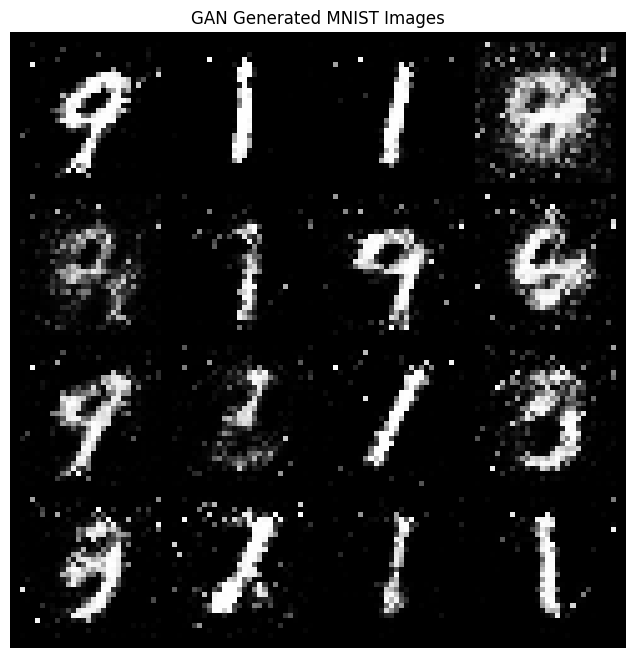

이미지 출력이 완료되었습니다.


In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import torchvision.utils as vutils

#→ PyTorch, 수치계산(numpy), 그래프출력(matplotlib), 이미지그리드 유틸(vutils) 임포트

print("이미지 생성 시작 (디바이스: cuda)")

G.eval()
#이제 학습끝났으니 시험을 시작한다

num_generate = 16
latent_size = 64 
#→ 이미지 16장 생성할 것, 노이즈 크기는 64차원

z = torch.randn(num_generate, latent_size).to(device)
#→ shape (16, 64)의 랜덤 노이즈 생성 후 GPU로 이동. 이 노이즈가 이미지 생성의 씨앗(seed) 역할

with torch.no_grad():
    fake_images_1d = G(z)
#→ 기울기 계산을 끔 (추론 단계에선 역전파 불필요 → 메모리/속도 절약). G에 노이즈를 통과시켜 가짜 이미지 생성. 
#결과 shape: (16, 784) - 16장의 이미지가 1차원으로 펼쳐진 상태
# 랜덤 숫자를 G에 넣어서 가짜 이미지 생성


fake_images_numpy = fake_images_1d.cpu().numpy()
#→ GPU 텐서 → CPU로 이동 → numpy 배열로 변환. 
#matplotlib은 numpy를 사용하기 때문에 변환 필요. shape 여전히 (16, 784)
fake_images_2d = fake_images_numpy.reshape(num_generate, 1, 28, 28)
# 1차원 배열을 정사각형 형태로 만든다

fake_images_normalized = fake_images_2d * 0.5 + 0.5
#→ Generator 출력은 Tanh 때문에 -1~1 범위. 
#학습전 바꿔두었던걸 0~1 범위로 되돌림
plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("GAN Generated MNIST Images")
#→ 8×8 인치 크기 그림 생성. 축(눈금) 숨김. 제목 설정
final_images_tensor = torch.from_numpy(fake_images_normalized)
#→ numpy 배열을 다시 PyTorch 텐서로 변환. vutils.make_grid가 텐서를 입력으로 받기 때문
grid_img = vutils.make_grid(final_images_tensor, nrow=4, padding=2, normalize=False)
# → 16장의 이미지를 4열 4행 격자로 배열. padding=2는 이미지 사이 간격 2픽셀. normalize=False는 이미 0~1로 정규화했으니 추가 정규화 안 함. 
#결과 shape: (3, H, W) - make_grid가 자동으로 3채널로 변환
plt.imshow(np.transpose(grid_img.numpy(), (1, 2, 0)), cmap='gray')
#→ 16장의 이미지를 4열 4행 격자로 배열. padding=2는 이미지 사이 간격 2픽셀. normalize=False는 이미 0~1로 정규화했으니 추가 정규화 안 함. 
#결과 shape: (3, H, W) - make_grid가 자동으로 3채널로 변환
plt.show()

print("이미지 출력이 완료되었습니다.")